In [76]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras import regularizers

%run plot.py

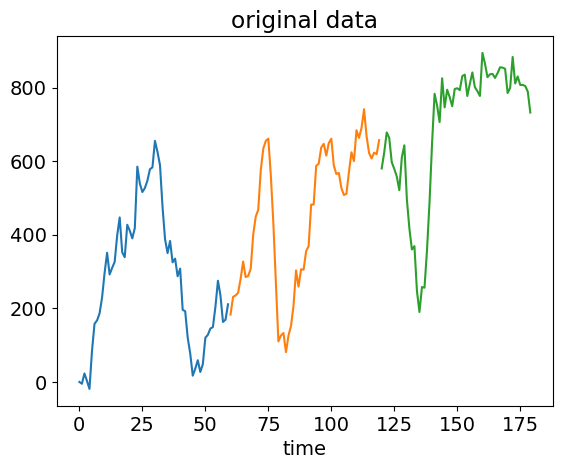

data:  10000


In [77]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1.

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


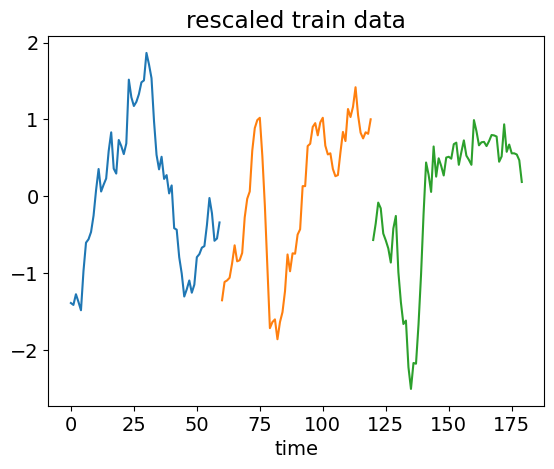

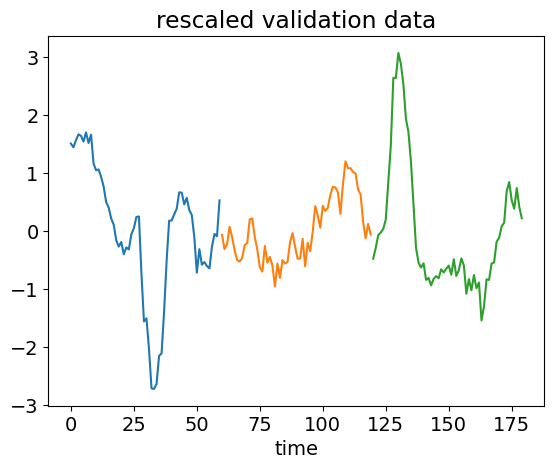

In [78]:

# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

 
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
for i in range(N_val):
    
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
#

    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)


In [79]:
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
def build_model(reg_type, lam, input_shape):
    if reg_type == 'l1':
        reg = regularizers.l1(lam)
    elif reg_type == 'l2':
        reg = regularizers.l2(lam)
    else:
        reg = regularizers.l1_l2(l1=lam, l2=lam)
    
    model = Sequential()
    model.add(Conv1D(filters=5, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, 
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

--- Studying Regularization: l1 ---


/home/sazzz/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Lambda=0.0: Accuracy=0.9690
  Lambda=1e-05: Accuracy=0.9775
  Lambda=0.0001: Accuracy=0.9675
  Lambda=0.001: Accuracy=0.9795
  Lambda=0.01: Accuracy=0.9810
  Lambda=0.1: Accuracy=0.8835
--- Studying Regularization: l2 ---
  Lambda=0.0: Accuracy=0.9670
  Lambda=1e-05: Accuracy=0.9665
  Lambda=0.0001: Accuracy=0.9830
  Lambda=0.001: Accuracy=0.9725
  Lambda=0.01: Accuracy=0.9580
  Lambda=0.1: Accuracy=0.9750
--- Studying Regularization: l1_l2 ---
  Lambda=0.0: Accuracy=0.9800
  Lambda=1e-05: Accuracy=0.9630
  Lambda=0.0001: Accuracy=0.9610
  Lambda=0.001: Accuracy=0.9730
  Lambda=0.01: Accuracy=0.9575
  Lambda=0.1: Accuracy=0.8605


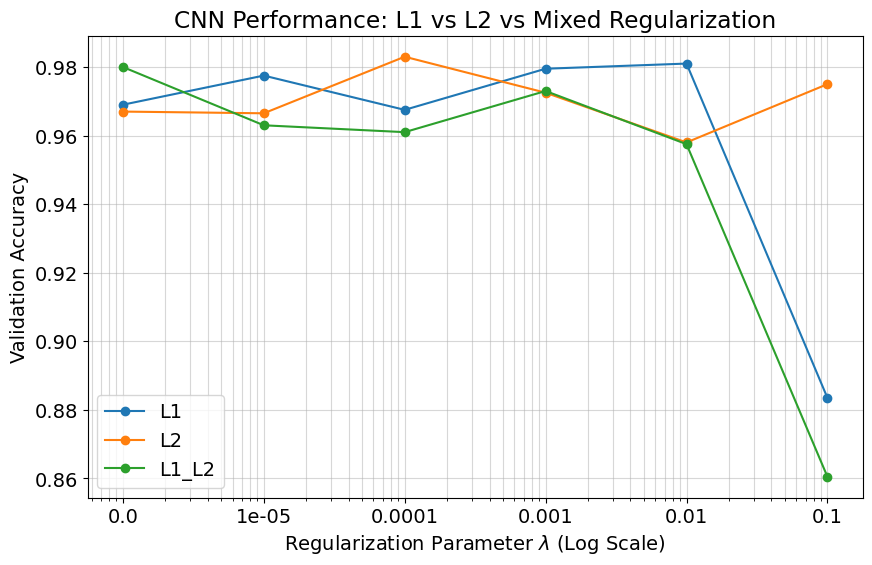

In [80]:
import matplotlib.pyplot as plt

# 1. Update the loop to store all results
lambdas = [0.0,1e-5, 1e-4, 1e-3, 1e-2,1e-1]
regula = ['l1', 'l2', 'l1_l2']
all_results = {r: [] for r in regula}

for reg in regula:
    print(f"--- Studying Regularization: {reg} ---")
    for l in lambdas:
        model = build_model(reg, l, input_shape)
        history = model.fit(x_train, y_train, epochs=20, batch_size=32, 
                            validation_data=(x_val, y_val), verbose=0)
        
        acc = history.history['val_accuracy'][-1]
        all_results[reg].append(acc)
        print(f"  Lambda={l}: Accuracy={acc:.4f}")

# 2. Plotting for comparison
plt.figure(figsize=(10, 6))

# Define a version of lambdas for the X-axis (treating 0 as a small value for log scale)
plot_lambdas = [l if l > 0 else 1e-6 for l in lambdas]

for reg in regula:
    plt.plot(plot_lambdas, all_results[reg], marker='o', label=reg.upper())

plt.xscale('log')
plt.xlabel('Regularization Parameter $\lambda$ (Log Scale)')
plt.ylabel('Validation Accuracy')
plt.title('CNN Performance: L1 vs L2 vs Mixed Regularization')
plt.grid(True, which="both", ls="-", alpha=0.5)

# Annotate the '0' point manually on the x-axis
plt.xticks(plot_lambdas, [str(l) for l in lambdas])

plt.legend()
plt.show()

Question 3.1:
Are performances of the CNN are optimized at some intermediate value of lambda?
Answer: Yes,
At Lambda=0 the models exhibit slightly lower or fluctuating validation accuracy. Without enough regularization, the filters may be picking up on noise in the training set (High Variance).
At lambda= 0.1 The model using L1 and l1_l2 exhibit a catastrophic drop in accuracy due to high bias. The penalty on weights is so high that the resulting learning tends towards 0. The model becomes too simple to represent the data.
At intermediate lambda: L2 shows peak in 0.0001, L1 peaks at 0.01, buut l1_l2 maintains good performance throughout the zone. 
Thus the regularizers perform better in the intermediate values of lambda.
Question 3.2:
Is there any improvement in the visualization and understanding of the weights in the
filters?